In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import pandas as pd
import time
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title Konfigurasi Path dan Penyiapan Folder Output

DATASET_TRAIN_PATH = "/content/drive/MyDrive/BERKAS_TA/Dataset/Type 2 Diabetes Mellitus Tongue Dataset/preprocessedcropped-20240821T085241Z-001/preprocessedcropped/train"

# Path foto puskesmas — tetap sebagai data pengujian eksternal saja
PUSKESMAS_PATH = "/content/drive/MyDrive/BERKAS_TA/Dataset/data_puskesmas1"

# Folder output untuk menyimpan model dan hasil
SAVE_DIR = "/content/drive/MyDrive/BERKAS_TA/Model4"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
RANDOM_SEED = 42

print(f"Dataset train : {DATASET_TRAIN_PATH}")
print(f"Puskesmas     : {PUSKESMAS_PATH}")
print(f"Output        : {SAVE_DIR}")

Dataset train : /content/drive/MyDrive/BERKAS_TA/Dataset/Type 2 Diabetes Mellitus Tongue Dataset/preprocessedcropped-20240821T085241Z-001/preprocessedcropped/train
Puskesmas     : /content/drive/MyDrive/BERKAS_TA/Dataset/data_puskesmas1
Output        : /content/drive/MyDrive/BERKAS_TA/Model4


In [ ]:
#@title Data Loader — Training & Validasi

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2                       # 20% untuk validasi
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Generator training
train_generator = train_datagen.flow_from_directory(
    DATASET_TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['nondiabetes', 'diabetes'],
    subset='training',          # 80%
    shuffle=True,
    seed=RANDOM_SEED
)

# Generator validasi
valid_generator = valid_datagen.flow_from_directory(
    DATASET_TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['nondiabetes', 'diabetes'],
    subset='validation',        # 20%
    shuffle=False,
    seed=RANDOM_SEED
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"Training      : {train_generator.samples} foto")
print(f"Validasi      : {valid_generator.samples} foto")

Found 1680 images belonging to 2 classes.
Found 420 images belonging to 2 classes.

Class indices : {'nondiabetes': 0, 'diabetes': 1}
Training      : 1680 foto
Validasi      : 420 foto


In [ ]:
#@title Membangun Arsitektur ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Fine-tuning: unfreeze 30 layer terakhir ResNet50
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,645,505 (94.02 MB)

 Trainable params: 15,503,873 (59.14 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5821 - loss: 0.8185
Epoch 1: val_accuracy improved from None to 0.69286, saving model to /content/drive/MyDrive/BERKAS_TA/Model4/best_model_resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BERKAS_TA/Model4/best_model_resnet50.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 659s 12s/step - accuracy: 0.6226 - loss: 0.7320 - val_accuracy: 0.6929 - val_loss: 0.5739 - learning_rate: 1.0000e-05
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7408 - loss: 0.5227
Epoch 2: val_accuracy improved from 0.69286 to 0.79286, saving model to /content/drive/MyDrive/BERKAS_TA/Model4/best_model_resnet50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/BERKAS_TA/Model4/best_model_resnet50.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 615s 12s/step - accuracy: 0.7738 - loss: 0.4724 - val_accuracy: 0.7929 - val_loss: 0.4497 - learning_rate: 1.0000e-05
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.

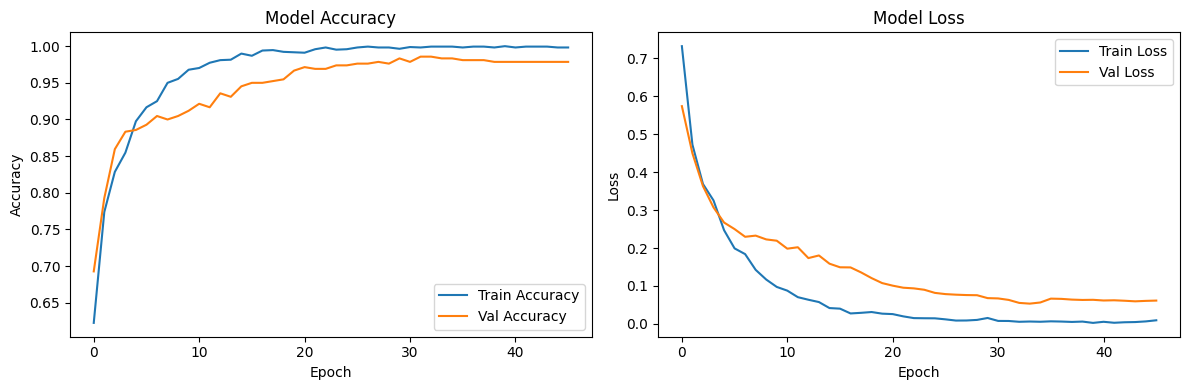

In [ ]:
#@title Proses Training Model

epochs = 100

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(SAVE_DIR, 'best_model_resnet50.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=epochs,
    callbacks=callbacks
)

# ── Plot Grafik Training ──────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "grafik_training.png"), dpi=150)
plt.show()

In [ ]:
#@title Statistik Dataset & Analisis Ciri Warna Lidah

def get_stats(directory, label=''):
    if not os.path.exists(directory):
        print(f"Folder tidak ditemukan: {directory}")
        return pd.DataFrame()

    classes = [d for d in os.listdir(directory)
               if os.path.isdir(os.path.join(directory, d))]
    stats = []

    for cls in classes:
        path      = os.path.join(directory, cls)
        file_list = [f for f in os.listdir(path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        num_files = len(file_list)

        sample_colors = []
        for img_name in file_list:
            img_cv = cv2.imread(os.path.join(path, img_name))
            if img_cv is not None:
                sample_colors.append(cv2.mean(img_cv)[:3])

        if sample_colors:
            avg_rgb = np.mean(sample_colors, axis=0)[::-1]
            stats.append({
                'Split': label,
                'Class': cls,
                'Count': num_files,
                'Avg_Red':   round(avg_rgb[0], 2),
                'Avg_Green': round(avg_rgb[1], 2),
                'Avg_Blue':  round(avg_rgb[2], 2)
            })

    return pd.DataFrame(stats)

# Hanya menggunakan folder train
df_train = get_stats(DATASET_TRAIN_PATH, label='train')

print("=" * 50)
print("STATISTIK DATASET TRAINING")
print("=" * 50)
print(df_train.to_string(index=False))

df_train.to_csv(os.path.join(SAVE_DIR, "statistik_dataset.csv"), index=False)

# Perbandingan intensitas merah antar kelas
diab_row = df_train[df_train['Class'] == 'diabetes']
norm_row = df_train[df_train['Class'] == 'nondiabetes']

if not diab_row.empty and not norm_row.empty:
    print(f"\nRata-rata Intensitas Merah - Diabetes   : {diab_row['Avg_Red'].values[0]:.2f}")
    print(f"Rata-rata Intensitas Merah - Non-diabetes: {norm_row['Avg_Red'].values[0]:.2f}")

STATISTIK DATASET TRAINING
Split       Class  Count  Avg_Red  Avg_Green  Avg_Blue
train    diabetes   1050   143.44     110.25    105.78
train nondiabetes   1050   149.01     112.24    117.06

Rata-rata Intensitas Merah - Diabetes   : 143.44
Rata-rata Intensitas Merah - Non-diabetes: 149.01


14/14 ━━━━━━━━━━━━━━━━━━━━ 92s 6s/step

CLASSIFICATION REPORT — DATA VALIDASI
              precision    recall  f1-score   support

 nondiabetes       0.98      0.99      0.98       210
    diabetes       0.99      0.98      0.98       210

    accuracy                           0.98       420
   macro avg       0.98      0.98      0.98       420
weighted avg       0.98      0.98      0.98       420

Sensitivity (Recall Diabetes)   : 0.9762
Specificity (Recall Non-diabetes): 0.9905


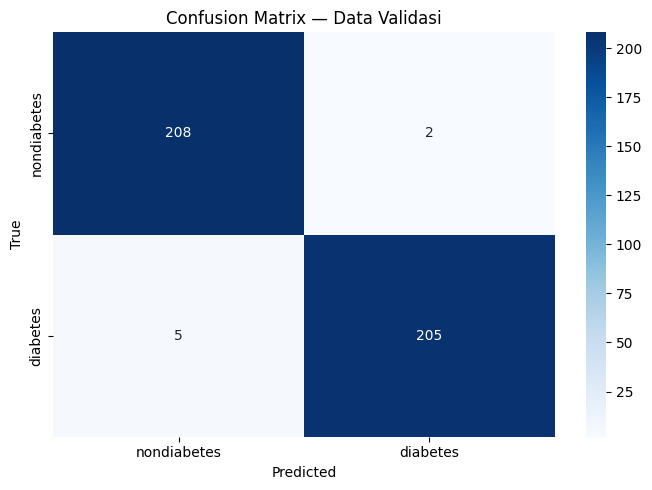

In [ ]:
#@title Evaluasi Metrik dan Confusion Matrix — Data Validasi

valid_generator.reset()

y_true          = valid_generator.classes
y_prob          = model.predict(valid_generator, verbose=1)
y_pred          = (y_prob > 0.5).astype(int).flatten()

# Label sesuai class_indices generator
label_map   = valid_generator.class_indices        # {'nondiabetes':0, 'diabetes':1}
idx_to_name = {v: k for k, v in label_map.items()}
target_names = [idx_to_name[i] for i in sorted(idx_to_name)]

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT — DATA VALIDASI")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # recall kelas positif (diabetes=1)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # recall kelas negatif (nondiabetes=0)

print(f"Sensitivity (Recall Diabetes)   : {sensitivity:.4f}")
print(f"Specificity (Recall Non-diabetes): {specificity:.4f}")

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names
)
plt.title('Confusion Matrix — Data Validasi')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix_validasi.png"), dpi=150)
plt.show()

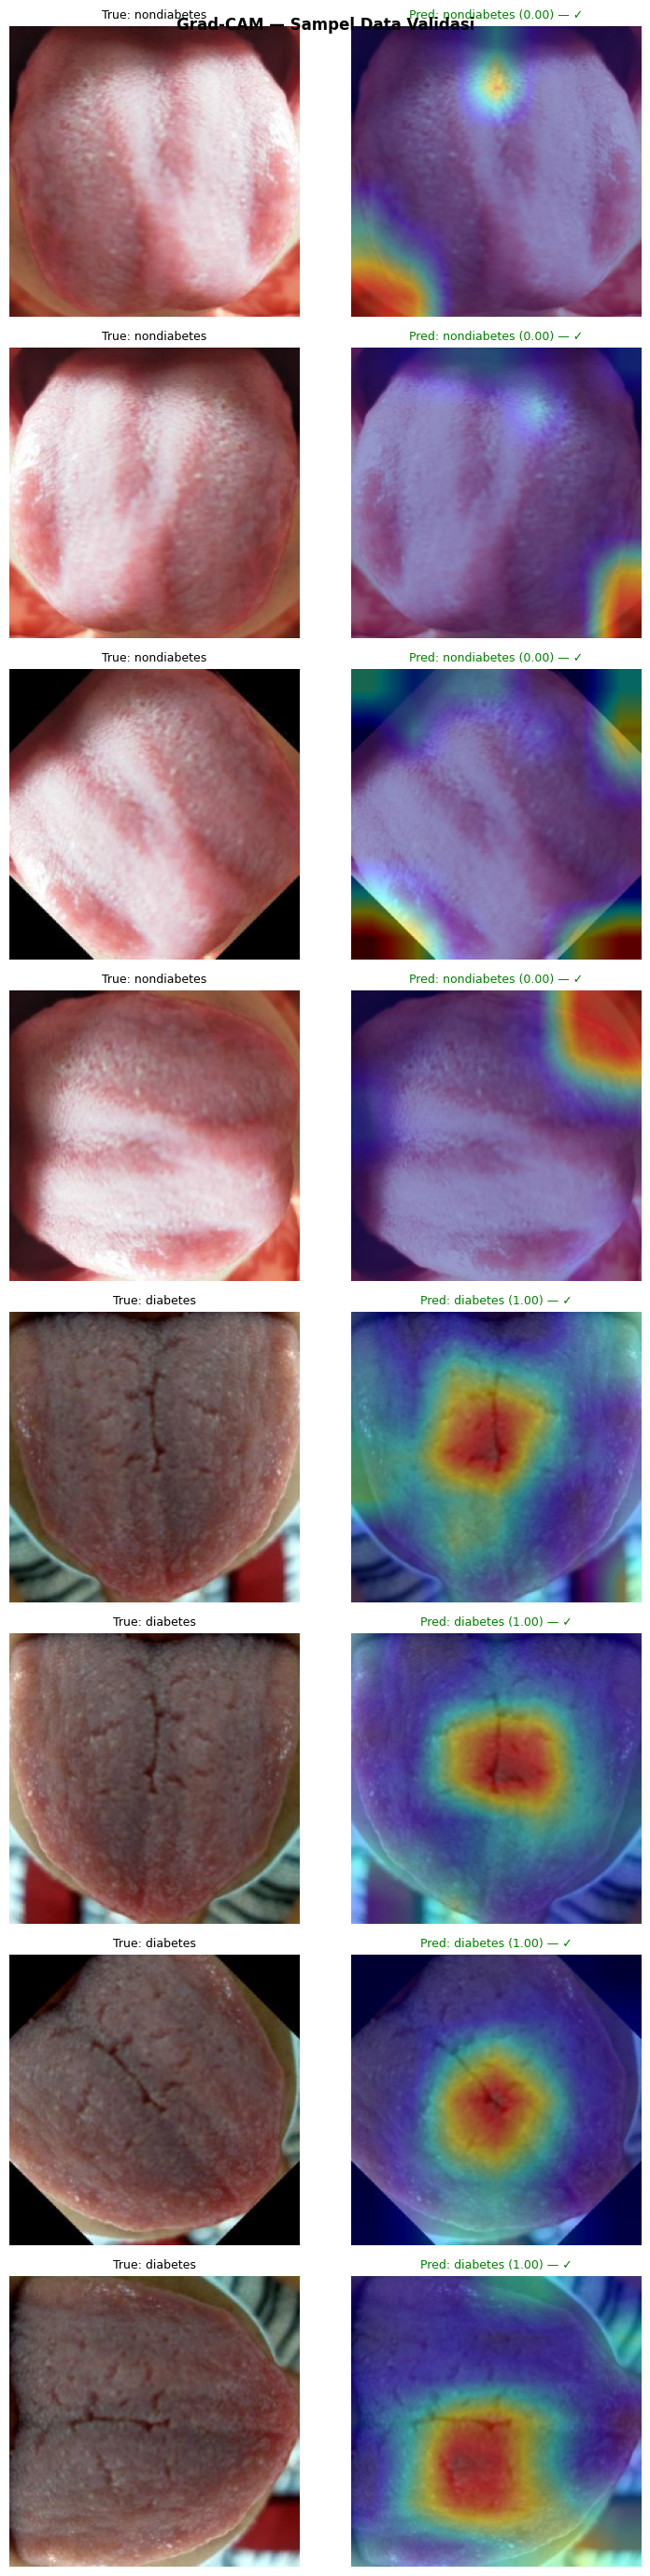

Grad-CAM validasi disimpan di: /content/drive/MyDrive/BERKAS_TA/Model4/gradcam_validasi.png


In [ ]:
#@title Visualisasi Grad-CAM — Sampel dari Data Validasi

GRADCAM_LAYER   = "conv5_block3_out"
N_SAMPLES       = 4   # jumlah sampel per kelas yang divisualisasikan

grad_model = Model(
    inputs=model.inputs,
    outputs=[model.get_layer(GRADCAM_LAYER).output, model.output]
)

label_map   = valid_generator.class_indices        # {'nondiabetes':0, 'diabetes':1}
idx_to_name = {v: k for k, v in label_map.items()}

# Ambil semua path file dari valid_generator
filepaths = valid_generator.filepaths
labels    = valid_generator.classes

# Pilih N_SAMPLES per kelas
samples = []
for class_idx in sorted(idx_to_name.keys()):
    idxs = [i for i, l in enumerate(labels) if l == class_idx][:N_SAMPLES]
    samples += [(filepaths[i], labels[i]) for i in idxs]

fig, axes = plt.subplots(len(samples), 2, figsize=(8, 3.5 * len(samples)))

for row, (img_path, true_label) in enumerate(samples):
    # Preprocessing
    img       = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Grad-CAM
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        tape.watch(conv_outputs)
        loss = preds[:, 0]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam          = (conv_outputs[0] @ pooled_grads[..., tf.newaxis]).numpy()
    cam          = np.squeeze(cam)
    cam          = np.maximum(cam, 0)
    cam          = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

    pred_prob  = float(preds[0][0])
    pred_label = 1 if pred_prob > 0.5 else 0
    is_correct = (pred_label == true_label)

    # Overlay
    img_cv        = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_cv        = cv2.resize(img_cv, (224, 224))
    cam_resized   = cv2.resize(cam, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay       = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)

    # Plot
    axes[row, 0].imshow(img_cv)
    axes[row, 0].set_title(f"True: {idx_to_name[true_label]}", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(
        f"Pred: {idx_to_name[pred_label]} ({pred_prob:.2f}) — {'✓' if is_correct else '✗'}",
        fontsize=9, color='green' if is_correct else 'red'
    )
    axes[row, 1].axis('off')

plt.suptitle("Grad-CAM — Sampel Data Validasi", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "gradcam_validasi.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM validasi disimpan di: {os.path.join(SAVE_DIR, 'gradcam_validasi.png')}")

In [ ]:
#@title Pengujian Data Puskesmas

pusk_output_dir = os.path.join(SAVE_DIR, "Hasil_Puskesmas")
os.makedirs(pusk_output_dir, exist_ok=True)

subfolders = ['non-diabetes', 'diabetes']
label_map        = train_generator.class_indices         # {'nondiabetes':0, 'diabetes':1}
idx_to_name      = {v: k for k, v in label_map.items()}  # {0:'nondiabetes', 1:'diabetes'}
subfolder_to_label = {
    'diabetes':     label_map['diabetes'],      # → 1
    'non-diabetes': label_map['nondiabetes'],   # → 0
}

results = []

print(f"Memulai pengujian data puskesmas di: {PUSKESMAS_PATH}\n")

for sub in subfolders:
    folder_path = os.path.join(PUSKESMAS_PATH, sub)

    if not os.path.exists(folder_path):
        print(f"[WARNING] Folder tidak ditemukan: {folder_path}. Lewat...")
        continue

    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    true_label = subfolder_to_label[sub]

    print(f"--- Memproses: {sub} ({len(files)} foto) | True label: {idx_to_name[true_label]} ---")

    for filename in files:
        try:
            img_path = os.path.join(folder_path, filename)

            # Preprocessing — konsisten dengan training
            img       = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            # Prediksi
            pred_prob  = float(model.predict(img_array, verbose=0)[0][0])
            pred_label = 1 if pred_prob > 0.5 else 0
            is_correct = (pred_label == true_label)
            status     = "BENAR" if is_correct else "SALAH"

            # Grad-CAM
            grad_model = Model(
                inputs=model.inputs,
                outputs=[model.get_layer("conv5_block3_out").output, model.output]
            )
            with tf.GradientTape() as tape:
                conv_outputs, preds = grad_model(img_array)
                tape.watch(conv_outputs)
                loss_val = preds[:, 0]

            grads_val    = tape.gradient(loss_val, conv_outputs)
            pooled_grads = tf.reduce_mean(grads_val, axis=(0, 1, 2))

            cam = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
            cam = tf.squeeze(cam).numpy()
            cam = np.maximum(cam, 0)
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

            img_cv        = cv2.imread(img_path)
            img_rgb       = cv2.resize(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), (224, 224))
            cam_resized   = cv2.resize(cam, (224, 224))
            heatmap_color = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
            result_img    = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

            # Simpan visualisasi
            plt.figure(figsize=(6, 3))
            plt.subplot(1, 2, 1); plt.imshow(img_rgb);    plt.axis('off'); plt.title("Asli")
            plt.subplot(1, 2, 2); plt.imshow(result_img); plt.axis('off')
            plt.title(
                f"True: {idx_to_name[true_label]}\nPred: {idx_to_name[pred_label]} ({pred_prob:.2f})\n{status}",
                color='green' if is_correct else 'red', fontsize=8
            )
            plt.suptitle(filename, fontsize=7, color='gray')
            plt.tight_layout()

            save_path = os.path.join(pusk_output_dir, f"{status}_{sub}_{filename}.png")
            plt.savefig(save_path, dpi=120, bbox_inches='tight')
            plt.close()

            results.append({
                'file':       filename,
                'folder':     sub,
                'true_label': idx_to_name[true_label],
                'pred_label': idx_to_name[pred_label],
                'prob':       round(pred_prob, 4),
                'correct':    is_correct
            })

            print(f"  {filename:30s} → {idx_to_name[pred_label]} ({pred_prob:.3f}) [{status}]")
            time.sleep(0.05)

        except Exception as e:
            print(f"  [ERROR] {filename}: {e}")
            continue

# Ringkasan hasil
df_results = pd.DataFrame(results)

print("\n" + "=" * 55)
print("RINGKASAN HASIL PENGUJIAN DATA PUSKESMAS")
print("=" * 55)

for folder in df_results['folder'].unique():
    sub_df = df_results[df_results['folder'] == folder]
    n_ok   = sub_df['correct'].sum()
    n      = len(sub_df)
    print(f"  {folder:15s}: {n_ok}/{n} benar ({100 * n_ok / n:.1f}%)")

total_ok = df_results['correct'].sum()
total    = len(df_results)
print(f"\n  TOTAL: {total_ok}/{total} benar ({100 * total_ok / total:.1f}%)")

# Simpan rekap
csv_path = os.path.join(SAVE_DIR, "hasil_puskesmas.csv")
df_results.to_csv(csv_path, index=False)
print(f"\n  Rekap CSV    : {csv_path}")
print(f"  Gambar Grad-CAM: {pusk_output_dir}")

Memulai pengujian data puskesmas di: /content/drive/MyDrive/BERKAS_TA/Dataset/data_puskesmas1

--- Memproses: non-diabetes (30 foto) | True label: nondiabetes ---
  non_1.jpeg                     → nondiabetes (0.391) [BENAR]
  non_2.jpeg                     → nondiabetes (0.163) [BENAR]
  non_3.jpeg                     → diabetes (1.000) [SALAH]
  non_5.jpeg                     → diabetes (0.993) [SALAH]
  non_4.jpeg                     → diabetes (1.000) [SALAH]
  non_6.jpeg                     → diabetes (0.943) [SALAH]
  non_7.jpeg                     → diabetes (0.997) [SALAH]
  non_8.jpeg                     → nondiabetes (0.195) [BENAR]
  non_9.jpeg                     → diabetes (0.981) [SALAH]
  non_10.jpeg                    → nondiabetes (0.014) [BENAR]
  non_11.jpeg                    → diabetes (0.973) [SALAH]
  non_12.jpeg                    → nondiabetes (0.000) [BENAR]
  non_13.jpeg                    → diabetes (0.928) [SALAH]
  non_14.jpeg                    → diabete

In [ ]:
#@title Simpan Model

import tensorflow as tf

# Simpan format Keras (untuk keperluan lanjutan / fine-tune ulang)
final_model_path = os.path.join(SAVE_DIR, "final_model_resnet50.keras")
model.save(final_model_path)
print(f"Model Keras disimpan : {final_model_path}")

# Konversi ke TFLite (untuk aplikasi mobile Flutter)
print("\nMengkonversi ke TFLite...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimasi ukuran file dengan dynamic range quantization
# Model jadi lebih kecil dan lebih cepat di mobile tanpa kehilangan akurasi signifikan
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_path = os.path.join(SAVE_DIR, "model_resnet50.tflite")
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"Model TFLite disimpan: {tflite_path}")
print(f"Ukuran file TFLite   : {os.path.getsize(tflite_path) / 1024 / 1024:.2f} MB")

#  Verifikasi TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\nTFLite Input shape : {input_details[0]['shape']}")   # harus [1, 224, 224, 3]
print(f"TFLite Output shape: {output_details[0]['shape']}")   # harus [1, 1]
print("\nVerifikasi selesai. Model siap dipakai di Flutter.")

Model Keras disimpan : /content/drive/MyDrive/BERKAS_TA/Model4/final_model_resnet50.keras

Mengkonversi ke TFLite...
Saved artifact at '/tmp/tmpgzjfu9m_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137111077638928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077639696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077639120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077640272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077637200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077637968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077641808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077643152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137111077645072: TensorSpec(shape=(),

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
